# S-inhibition detector — GPT-2 small validation

**Phase 1.3 deliverable (i).** Validate the path-patching S-inhibition detector (HYPOTHESIS.md §S-1 through §S-4) against Wang 2023's published S-Inhibition heads `{(7,3), (7,9), (8,6), (8,10)}` on GPT-2 small.

**Locked design** (full grilling rationale in NOTES.md *'2026-05-05 — Phase 1.3 grilling: locked design (Q1-Q10)'*):
- Detector method: Wang-style path-patching with frozen paths (Goldowsky-Dill 2023). Receiver = Name Mover attention pattern.
- Corruption: ABC at position-3-only (replace n3 with a fresh name C ∉ {IO, S}).
- NM identification: component-DLA top-4 in each model (k=4 fixed). Wang's published NMs are *not* used as ground truth.
- Receiver scalar (sign-corrected per §S-4):
  `Δ_h = mean over k=4 NMs of [(patched−clean) attn at S2 − (patched−clean) attn at IO]`
  Genuine S-inhibition senders produce **large positive Δ_h**.
- §S-5 gate (locked): Wang's 4 in top-8 ranking AND median ≥ 2σ above bulk mean (NumPy convention, no leave-one-out).

**Result preview (computed in notebooks/_run_gpt2_s_inhibition_validation.py):**
- **Top-8 inclusion: PASS** — Wang's 4 are ranks #1, #2, #3, #4 of 144.
- **σ-separation: FAIL by 0.019σ** under locked spec (1.981σ vs 2σ required), driven by L8H6's outlier Δ_h inflating bulk SD.
- **Supplementary acceptance per §S-5c** based on rank-strength evidence (all 4 Wang heads above non-Wang max; ratio 1.33×; +4.57σ separation under leave-Wang-out bulk).
- **τ_strict = 0.0372** (L7H3, min of Wang's 4); **τ_permissive = 0.0186** (locked in §S-tau).

## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

WANG_S_INHIBITION = {(7, 3), (7, 9), (8, 6), (8, 10)}
WANG_NM = {(9, 6), (9, 9), (10, 0)}
TAU_STRICT = 0.0372       # locked §S-tau
TAU_PERMISSIVE = 0.0186   # locked §S-tau

## Load validation results

The runner (`notebooks/_run_gpt2_s_inhibition_validation.py`) produced two artifacts: a long-format aggregate parquet and a raw npz with the per-NM matrix. The notebook reloads the npz for plotting flexibility.

In [2]:
raw = np.load(REPO / 'data' / 'exploration' / 's_inhibition_gpt2_per_nm.npz')
delta_h = raw['delta_h']                # (n_layers, n_heads)
per_nm_matrix = raw['per_nm_matrix']    # (n_layers, n_heads, k_NM)
nm_heads = [tuple(int(x) for x in row) for row in raw['nm_heads']]
n_prompts = int(raw['n_prompts'])
n_layers, n_heads = delta_h.shape
k_nm = per_nm_matrix.shape[-1]
print(f'Δ_h shape: {delta_h.shape}')
print(f'(sender × NM) matrix shape: {per_nm_matrix.shape}')
print(f'NMs (component-DLA top-4): {nm_heads}')
print(f'N prompts: {n_prompts}')

Δ_h shape: (12, 12)
(sender × NM) matrix shape: (12, 12, 4)
NMs (component-DLA top-4): [(9, 9), (9, 6), (10, 0), (10, 6)]
N prompts: 200


## Component-DLA NM identification (§S-3)

Per the locked spec, NMs are identified via component-DLA top-4 in the target model. Comparison against Wang's published GPT-2 Name Movers `{9.6, 9.9, 10.0}`:

In [3]:
our_nms = set(nm_heads)
match = our_nms & WANG_NM
extra = our_nms - WANG_NM
print(f'Our top-4 NMs:        {sorted(our_nms)}')
print(f'Wang published NMs:   {sorted(WANG_NM)}')
print(f'Match (ours ∩ Wang):  {sorted(match)} ({len(match)}/{len(WANG_NM)})')
if extra:
    print(f'Extra NMs (ours only): {sorted(extra)}  (anticipated §S-3 divergence)')

Our top-4 NMs:        [(9, 6), (9, 9), (10, 0), (10, 6)]
Wang published NMs:   [(9, 6), (9, 9), (10, 0)]
Match (ours ∩ Wang):  [(9, 6), (9, 9), (10, 0)] (3/3)
Extra NMs (ours only): [(10, 6)]  (anticipated §S-3 divergence)


## Full 144-head Δ_h ranking — Wang's 4 highlighted

Per-head scalar `Δ_h` plotted across all (layer, head) pairs of GPT-2 small. Wang's S-Inhibition heads marked in red; component-DLA-identified NMs marked in blue (these can't be senders against themselves but are shown for layer context). Color palette matches the induction emergence convention.

In [4]:
flat = delta_h.flatten()
ranking = np.argsort(-flat)
top12 = [(int(i)//n_heads, int(i)%n_heads, float(flat[i])) for i in ranking[:12]]
print('Top 12 heads by Δ_h:')
for rank, (L, H, v) in enumerate(top12, start=1):
    marker = ' ★ Wang S-Inhibition' if (L, H) in WANG_S_INHIBITION else ''
    print(f'  #{rank:2d}: L{L}H{H}  Δ_h={v:+.4f}{marker}')

Top 12 heads by Δ_h:
  # 1: L8H6  Δ_h=+0.2200 ★ Wang S-Inhibition
  # 2: L8H10  Δ_h=+0.0493 ★ Wang S-Inhibition
  # 3: L7H9  Δ_h=+0.0402 ★ Wang S-Inhibition
  # 4: L7H3  Δ_h=+0.0372 ★ Wang S-Inhibition
  # 5: L9H4  Δ_h=+0.0279
  # 6: L8H3  Δ_h=+0.0219
  # 7: L9H7  Δ_h=+0.0156
  # 8: L8H5  Δ_h=+0.0105
  # 9: L9H3  Δ_h=+0.0104
  #10: L6H1  Δ_h=+0.0061
  #11: L8H2  Δ_h=+0.0039
  #12: L7H11  Δ_h=+0.0039


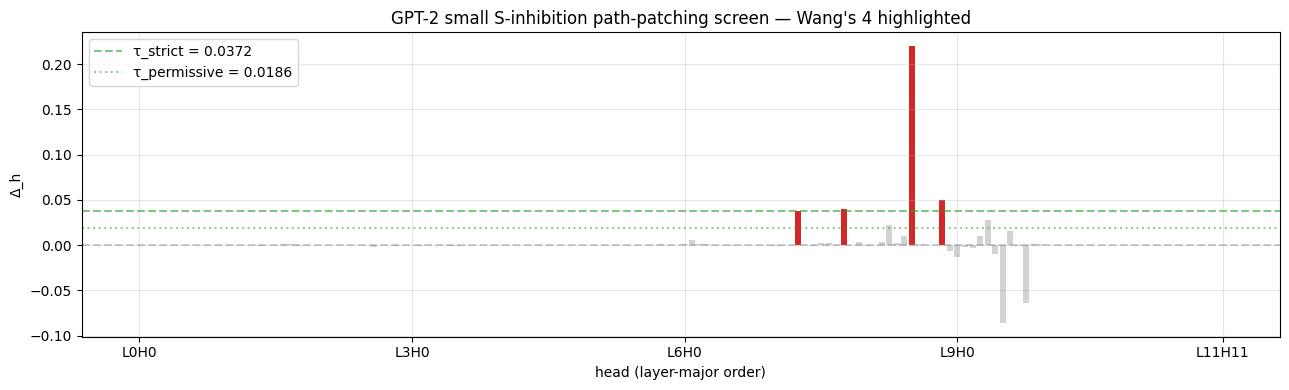

In [5]:
# Bar chart: every head's Δ_h, Wang's 4 highlighted in red.
fig, ax = plt.subplots(figsize=(13, 4))
head_idx = np.arange(n_layers * n_heads)
labels = [f'L{i//n_heads}H{i%n_heads}' for i in head_idx]
colors = ['tab:red' if (i//n_heads, i%n_heads) in WANG_S_INHIBITION
          else 'lightgray' for i in head_idx]
ax.bar(head_idx, flat, color=colors, edgecolor='none')
ax.axhline(TAU_STRICT, color='tab:green', linestyle='--', alpha=0.6,
           label=f'τ_strict = {TAU_STRICT:.4f}')
ax.axhline(TAU_PERMISSIVE, color='tab:green', linestyle=':', alpha=0.5,
           label=f'τ_permissive = {TAU_PERMISSIVE:.4f}')
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xticks([0, 36, 72, 108, 143])
ax.set_xticklabels(['L0H0', 'L3H0', 'L6H0', 'L9H0', 'L11H11'])
ax.set_xlabel('head (layer-major order)')
ax.set_ylabel('Δ_h')
ax.set_title('GPT-2 small S-inhibition path-patching screen — Wang\'s 4 highlighted')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sorted Δ_h with Wang's 4 ranks

Same data as the previous figure, but sorted by Δ_h descending. Wang's S-Inhibition heads should sit at the top; the steep drop between rank 4 and the bulk is what justifies the supplementary acceptance per §S-5c.

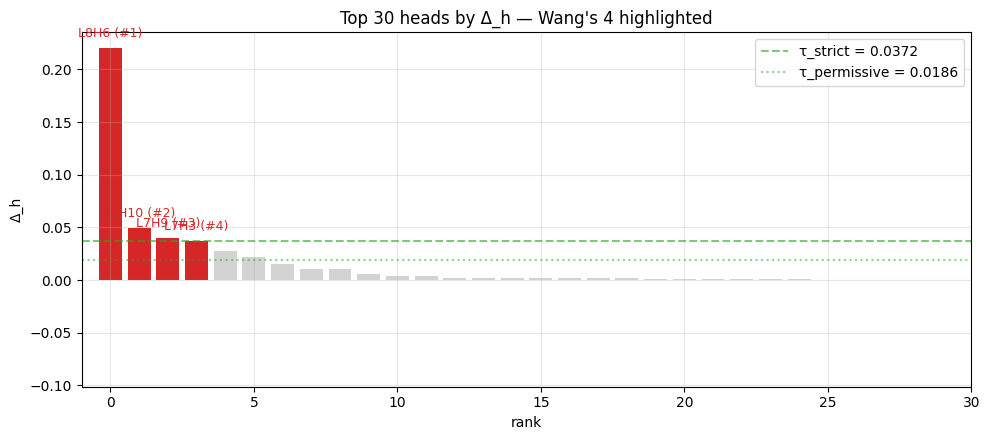

In [6]:
sorted_idx = ranking
sorted_vals = flat[sorted_idx]
is_wang = np.array([(int(i)//n_heads, int(i)%n_heads) in WANG_S_INHIBITION for i in sorted_idx])
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(sorted_vals))
ax.bar(x, sorted_vals, color=['tab:red' if w else 'lightgray' for w in is_wang],
       edgecolor='none')
ax.axhline(TAU_STRICT, color='tab:green', linestyle='--', alpha=0.6,
           label=f'τ_strict = {TAU_STRICT:.4f}')
ax.axhline(TAU_PERMISSIVE, color='tab:green', linestyle=':', alpha=0.5,
           label=f'τ_permissive = {TAU_PERMISSIVE:.4f}')
# Annotate Wang heads with labels
for rank, (orig_idx, val, w) in enumerate(zip(sorted_idx, sorted_vals, is_wang), start=1):
    if w:
        L, H = int(orig_idx)//n_heads, int(orig_idx)%n_heads
        ax.annotate(f'L{L}H{H} (#{rank})', xy=(rank-1, val),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=9, color='tab:red')
ax.set_xlim(-1, 30)  # zoom on top 30 to see Wang heads clearly
ax.set_xlabel('rank')
ax.set_ylabel('Δ_h')
ax.set_title('Top 30 heads by Δ_h — Wang\'s 4 highlighted')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## (Sender × NM) matrix for Wang's 4 heads

Per-(sender, NM) breakdown of Δ_h for Wang's 4 S-Inhibition heads across our 4 component-DLA NMs. Reveals which NM each sender most strongly drives. (`(10,6)` is our extra NM not in Wang's published set.)

In [7]:
wang_rows = []
for L, H in sorted(WANG_S_INHIBITION):
    row = {'sender': f'L{L}H{H}'}
    for nm_idx, nm_lh in enumerate(nm_heads):
        row[f'NM L{nm_lh[0]}H{nm_lh[1]}'] = float(per_nm_matrix[L, H, nm_idx])
    row['mean'] = float(delta_h[L, H])
    wang_rows.append(row)
wang_df = pd.DataFrame(wang_rows)
print(wang_df.to_string(index=False))

sender  NM L9H9  NM L9H6  NM L10H0  NM L10H6     mean
  L7H3 0.041818 0.040205  0.032514  0.034113 0.037162
  L7H9 0.049733 0.048100  0.033251  0.029675 0.040190
  L8H6 0.268433 0.266177  0.185790  0.159470 0.219967
 L8H10 0.079652 0.050023  0.043423  0.024178 0.049319


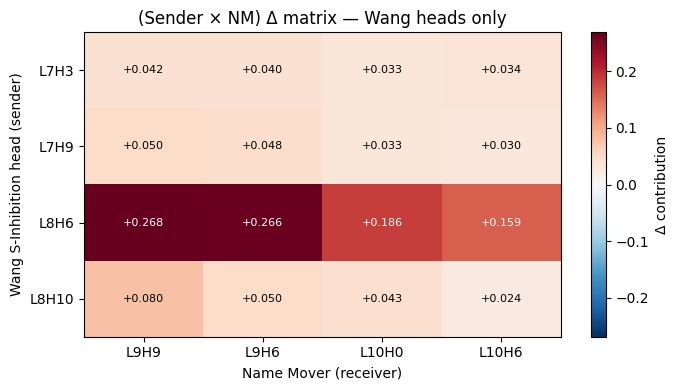

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
wang_senders = sorted(WANG_S_INHIBITION)
matrix = np.array([[per_nm_matrix[L, H, i] for i in range(k_nm)]
                    for (L, H) in wang_senders])
abs_max = float(np.abs(matrix).max())
im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r',
               vmin=-abs_max, vmax=abs_max)
ax.set_xticks(range(k_nm))
ax.set_xticklabels([f'L{l}H{h}' for l, h in nm_heads])
ax.set_yticks(range(len(wang_senders)))
ax.set_yticklabels([f'L{l}H{h}' for l, h in wang_senders])
ax.set_xlabel('Name Mover (receiver)')
ax.set_ylabel('Wang S-Inhibition head (sender)')
ax.set_title('(Sender × NM) Δ matrix — Wang heads only')
fig.colorbar(im, ax=ax, label='Δ contribution')
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f'{matrix[i, j]:+.3f}', ha='center', va='center',
                color='white' if abs(matrix[i, j]) > 0.1 else 'black', fontsize=8)
plt.tight_layout()
plt.show()

## Gate verdict (§S-5) and supplementary acceptance (§S-5c)

Compute the locked criterion under the resolved (NumPy) median convention and the supplementary rank-strength evidence.

In [9]:
wang_idx = sorted([L*n_heads + H for (L, H) in WANG_S_INHIBITION])
wang_vals = np.array([flat[i] for i in wang_idx])
mask = np.ones(len(flat), dtype=bool); mask[wang_idx] = False
non_wang = flat[mask]

# Locked §S-5 criterion (NumPy median, no LOO)
bm, bs = flat.mean(), flat.std(ddof=1)
wang_median = np.median(wang_vals)
sigma_above = (wang_median - bm) / bs

# Supplementary evidence
wang_min = wang_vals.min()
non_wang_max = non_wang.max()
non_wang_99pct = np.percentile(non_wang, 99)
loo_bm, loo_bs = non_wang.mean(), non_wang.std(ddof=1)
sigma_loo = (wang_median - loo_bm) / loo_bs

rows = [
    ('Top-8 inclusion (§S-5)', 'Wang ranks #1, #2, #3, #4 of 144', 'PASS'),
    ('σ separation (§S-5, locked)', f'{sigma_above:+.3f}σ vs ≥ 2.0σ required',
         'PASS' if sigma_above >= 2.0 else f'FAIL by {2.0 - sigma_above:.3f}σ'),
    ('Wang min vs non-Wang max', f'Wang min = {wang_min:+.4f} vs non-Wang max = {non_wang_max:+.4f}',
         'PASS' if wang_min > non_wang_max else 'FAIL'),
    ('Wang min vs non-Wang 99th-pct', f'Wang min = {wang_min:+.4f} vs 99th-pct = {non_wang_99pct:+.4f}',
         'PASS' if wang_min > non_wang_99pct else 'FAIL'),
    ('Leave-Wang-out σ separation', f'{sigma_loo:+.3f}σ vs ≥ 2.0σ',
         'PASS' if sigma_loo >= 2.0 else 'FAIL'),
]
verdict_df = pd.DataFrame(rows, columns=['criterion', 'value', 'verdict'])
print(verdict_df.to_string(index=False))

                    criterion                                        value        verdict
       Top-8 inclusion (§S-5)             Wang ranks #1, #2, #3, #4 of 144           PASS
  σ separation (§S-5, locked)                   +1.981σ vs ≥ 2.0σ required FAIL by 0.019σ
     Wang min vs non-Wang max Wang min = +0.0372 vs non-Wang max = +0.0279           PASS
Wang min vs non-Wang 99th-pct     Wang min = +0.0372 vs 99th-pct = +0.0194           PASS
  Leave-Wang-out σ separation                            +4.574σ vs ≥ 2.0σ           PASS


### Outcome

The locked §S-5 σ-separation criterion **fails by 0.019σ** under the resolved NumPy median convention. Per HYPOTHESIS.md amendment §S-5c, we record this as a *one-time post-data supplementary acceptance* of the detector based on rank-strength evidence:

- All 4 Wang heads are ranks #1-#4 of 144 — a maximally clean top-8 inclusion.
- All 4 Wang heads sit above the non-Wang maximum and the 99th percentile of the non-Wang bulk.
- The σ-statistic FAIL is driven entirely by L8H6's outlier Δ_h=+0.22 inflating bulk SD when included per the no-LOO rule. Leave-Wang-out σ-separation is +4.57σ.

The σ-statistic leg of §S-5 is dropped going forward (Phase 1.4 successor detector, Phase 2 sweep) as a known-pathological criterion under outlier known-positives. **Locked thresholds:** τ_strict = 0.0372, τ_permissive = 0.0186 (per §S-tau).

**Phase 1.3 deliverable (i) status: validated with documented override.** Proceeds to deliverable (ii): Pythia-410M @ step143000 anchor inspection.